# M01. Batted Balls

### Imports

In [1]:
from U01Imports import *
from U02Functions import *
from U03Classes import *
from U04Datasets import *
from U05Models import *

from B01Matchups import *

Using device: cuda


Batted Ball Angle Note:
- if y > 198.27 and x < 125.42), it's actually to left
- if y > 198.27 and x > 125.42), it's actually to right

### Settings

In [2]:
start_year, end_year = 2015, 2026  # Years to include in the batted ball dataset
num_games = 81                     # Number of games to roll for PFX calculations
short, long = 50, 300              # Number of PAs to roll for short and long term rates
train_batted_ball_model = True    # Train model (Shouldn't need to be run often)

# Train/test date windows (YYYYMMDD ints, matching df['date'])
min_training_date, max_training_date = 20210101, 20260630
min_testing_date,  max_testing_date  = 20250101, 20260630
if "is_main" not in globals():
    is_main = True

Training/Testing Protocol:
1. Finding the best parameters for 2025:
    - Parameters: In dictionary, as many runs of each as you'd like
    - Train: Through 2023
    - Test: Through 2024
2. Building the best model for 2025
    - Parameters: Best from step 1, just one run.
    - Train: Through 2024
    - Test: Doesn't matter, but you can do through 2025 for fun

In [3]:
print("Training batted ball model:", train_batted_ball_model and is_main)

Training batted ball model: True


### Data

##### MLB Stats API

Merge MLB Stats API and Statcast data

In [4]:
df = merge_datasets(start_year, end_year)
df = clean_weather(df)
df = create_events(df)
df = create_variables(df)
df = start_data(df)

##### Steamer

In [5]:
steamer_hitters_df = pd.read_csv(os.path.join(baseball_path, "A03. Steamer", "Hitters", "Steamer Hitters Dataset.csv"), encoding='iso-8859-1', usecols=['gamedate', 'mlbamid', 'PA', 'UBR'], dtype='str')

In [8]:
df['hit_distance_sc'].describe()

count   1302950.000000
mean        167.463283
std         136.506773
min           0.000000
25%          20.000000
50%         162.000000
75%         291.000000
max         505.000000
Name: hit_distance_sc, dtype: float64

### Clean

##### MLB Stats API

Format data types for merge

In [6]:
df['gamedate'] = pd.to_datetime(df['date'], format='%Y%m%d')
df['mlbamid'] = df['batter'].astype(str)

Sent launch data to 0 if not batted

In [7]:
df[['launch_angle', 'launch_speed']] = df[['launch_angle', 'launch_speed']].fillna(0)

##### Steamer

Convert data types

In [8]:
steamer_hitters_df[['PA', 'UBR']] = steamer_hitters_df[['PA', 'UBR']].astype(float)
steamer_hitters_df['gamedate'] = pd.to_datetime(steamer_hitters_df['gamedate'])

Calculate UBR per 600 Plate Appearances

In [9]:
steamer_hitters_df['UBR600'] = steamer_hitters_df['UBR'] / steamer_hitters_df['PA'] * 600

### Merge

In [10]:
df = pd.merge_asof(
    df.sort_values('gamedate'),
    steamer_hitters_df[['gamedate', 'mlbamid', 'PA', 'UBR600']].sort_values('gamedate'),
    by='mlbamid',
    on='gamedate',
    direction='backward'
)

### Inputs

In [11]:
batted_ball_inputs = ['launch_angle', 'launch_speed', 'to_l', 'to_lc', 'to_c', 'to_rc', 'to_r', 'b_L', 'UBR600'] + ['bb', 'hbp', 'so']

### Sample

Remove atypical events and missings

In [12]:
df = df[~df['eventsModel'].isin(["Cut"])].dropna(subset=batted_ball_inputs)

Define model input and outputs

In [13]:
X = df[batted_ball_inputs].values
y = df[['eventsModel']].values

##### Train/Test Split

In [14]:
# Boolean masks for train/test windows based on df['date'] (YYYYMMDD int)
train_mask = df['date'].between(min_training_date, max_training_date).values
test_mask  = df['date'].between(min_testing_date,  max_testing_date).values

print(f"Train rows: {train_mask.sum():,} ({min_training_date}-{max_training_date})")
print(f"Test rows:  {test_mask.sum():,} ({min_testing_date}-{max_testing_date})")

Train rows: 1,005,020 (20210101-20260630)
Test rows:  279,777 (20250101-20260630)


### Model

Probability of events given how the baseball was launched, where it was launched to, and some information about the batter, including handedness and base running. Notably excluding park and weather.

$ \hat{\text{eventsModel}} = launch\_angle + launch\_speed + to\_l + to\_lc + to\_c + to\_rc + to\_r + b\_L + UBR600 $

##### Encode

In [15]:
if is_main == True and train_batted_ball_model == True:
    # One-hot eventsModel (fit on full label set)
    encode_outcome = OneHotEncoder(sparse_output=False)
    y_encoded = encode_outcome.fit_transform(y)
    os.makedirs(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate), exist_ok=True)
    pickle.dump(encode_outcome, open(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, "encode_outcome.pkl"), 'wb'))
else:
    # Just transform with the loaded encoder
    y_encoded = encode_outcome.transform(y)

##### Scale

In [16]:
if is_main == True and train_batted_ball_model == True:
    # Scale model inputs — fit on the TRAINING window only, then transform all rows
    scale_inputs = StandardScaler()
    scale_inputs.fit(X[train_mask])
    X_scaled = scale_inputs.transform(X)
    pickle.dump(scale_inputs, open(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, "scale_inputs.pkl"), 'wb'))
else:
    # Just transform with the loaded scaler
    X_scaled = scale_inputs.transform(X)

##### Train (Multi-Parameter Sweep)

Define candidate configurations below and train them on the **training** window, evaluating each on the **testing** window via **wOBA buckets**. Run with a limited date window / small configs first, prune `model_a_configs` down to the winner(s), then widen `min_training_date`/`max_training_date` to the full sample and rerun. The best config's model, scaler, and encoder are saved and `predict_outcome` is set to the winner for the prediction step below.

##### Evaluation Helper (wOBA buckets)

In [17]:
# Evaluate predicted vs. actual on the testing window, bucketed by predicted wOBA.
# `pred_probs` is an (n_rows x n_classes) array aligned to `class_names`.
woba_weights = {'b1': 0.882, 'b2': 1.254, 'b3': 1.590, 'hr': 2.050, 'bb': 0.689, 'hbp': 0.720}

def evaluate_batted_ball(pred_probs, class_names, eventsModel, test_mask, n_buckets=20, year_label='All'):
    """Return (summary_df, bucket_df) of predicted-vs-actual on the testing window.

    summary_df: one row per event + a wOBA row, with Actual/Predicted/Multiplier/Std/MSE.
    bucket_df:  per-wOBA-bucket mean predicted vs. actual wOBA (for plotting).
    """
    classes = list(class_names)
    P = pd.DataFrame(pred_probs, columns=classes)

    # Actual one-hot for the same rows
    ev = pd.Series(np.asarray(eventsModel).ravel()).reset_index(drop=True)
    A = pd.DataFrame({c: (ev == c).astype(float) for c in classes})

    tm = np.asarray(test_mask)
    P_t, A_t = P[tm].reset_index(drop=True), A[tm].reset_index(drop=True)

    woba_events = [e for e in woba_weights if e in classes]
    woba_pred = sum(woba_weights[e] * P_t[e] for e in woba_events)
    woba_act  = sum(woba_weights[e] * A_t[e] for e in woba_events)

    # --- Per-event + wOBA summary ---
    rows = []
    for e in classes:
        pred_m, act_m = P_t[e].mean(), A_t[e].mean()
        # bucket MSE (calibration) for this event
        b = pd.qcut(P_t[e], q=n_buckets, duplicates='drop', labels=False)
        bk = pd.DataFrame({'pred': P_t[e], 'act': A_t[e], 'b': b}).groupby('b').mean()
        mse = ((bk['pred'] - bk['act'])**2).mean()
        rows.append([year_label, e, act_m, pred_m, act_m/pred_m if pred_m else np.nan, P_t[e].std(), mse])

    # wOBA row
    wb = pd.qcut(woba_pred, q=n_buckets, duplicates='drop', labels=False)
    woba_bucket = pd.DataFrame({'pred': woba_pred, 'act': woba_act, 'b': wb}).groupby('b').mean().reset_index()
    woba_mse = ((woba_bucket['pred'] - woba_bucket['act'])**2).mean()
    rows.append([year_label, 'wOBA', woba_act.mean(), woba_pred.mean(),
                 woba_act.mean()/woba_pred.mean() if woba_pred.mean() else np.nan,
                 woba_pred.std(), woba_mse])

    summary_df = pd.DataFrame(rows, columns=['Year','Output','Actual','Predicted','Multiplier','Std. Dev','MSE'])
    return summary_df, woba_bucket

##### Settings

In [18]:
n_runs = 5      # Random-seed runs per config — best wOBA MSE (test window) is kept
n_buckets = 20  # wOBA quantile buckets for evaluation

# Workflow: start with several configs on a limited window (set min/max_training_date
# narrow above). Compare on the test window, prune model_a_configs to the winner(s),
# widen the training window to the full sample, and rerun to train the final model.
# Each entry varies architecture, learning rate, L2 regularization, batch size, epochs.
model_a_configs = {
    # "A_64x32_lr1e4":    {'hidden_layer_sizes': (64, 32),    'learning_rate_init': 0.0001, 'alpha': 0.0,    'batch_size': 128, 'max_iter': 50},
    # "A_28x64_lr1e3":   {'hidden_layer_sizes': (128, 64),   'learning_rate_init': 0.001,  'alpha': 0.0,    'batch_size': 256, 'max_iter': 50},
    "A_32x64x32_lr1e4":    {'hidden_layer_sizes': (32, 64, 32),    'learning_rate_init': 0.0001, 'alpha': 0.0,    'batch_size': 128, 'max_iter': 50},
    # "A_64x128x64_lr1e3":   {'hidden_layer_sizes': (64, 128, 64),   'learning_rate_init': 0.001,  'alpha': 0.0,    'batch_size': 256, 'max_iter': 50},
    # "A_64x128x64_reg1e4":  {'hidden_layer_sizes': (64, 128, 64),   'learning_rate_init': 0.001,  'alpha': 0.0001, 'batch_size': 256, 'max_iter': 75},
    # "A_128x256x128_lr1e3": {'hidden_layer_sizes': (128, 256, 128), 'learning_rate_init': 0.001,  'alpha': 0.0,    'batch_size': 512, 'max_iter': 75},
}

##### Train, Predict, and Evaluate

In [19]:
import tensorflow as tf
from tensorflow.keras import regularizers

# Multi-parameter sweep. Trains each config in `model_a_configs` on the training
# window, evaluates on the testing window by wOBA-bucket MSE, keeps the best seed
# run per config, saves the best config overall, and sets `predict_outcome` to it.
if is_main == True and train_batted_ball_model == True:
    save_dir = os.path.join(model_path, "M01. Park and Weather Factors", todaysdate)
    os.makedirs(save_dir, exist_ok=True)

    class_names = list(encode_outcome.categories_[0])
    X_tr, y_tr = X_scaled[train_mask], y_encoded[train_mask]
    eventsModel_all = df['eventsModel'].values

    config_results = {}   # config_name -> best summary_df
    config_buckets = {}   # config_name -> best wOBA bucket_df
    best_overall = {'config': None, 'woba_mse': float('inf'), 'model': None,
                    'random_state': None, 'summary': None}

    for config_name, params in model_a_configs.items():
        print(f"\n{'='*60}\nConfig: {config_name}\n  {params}\n{'='*60}")
        best_cfg = {'woba_mse': float('inf'), 'model': None, 'random_state': None,
                    'summary': None, 'bucket': None}

        for run_idx in range(n_runs):
            random_state = random.randint(10000, 90000)
            np.random.seed(random_state)
            tf.random.set_seed(random_state)

            layers = params['hidden_layer_sizes']
            reg = regularizers.l2(params['alpha']) if params['alpha'] else None
            model = Sequential(
                [Dense(layers[0], input_shape=(X_tr.shape[1],), activation='relu', kernel_regularizer=reg)]
                + [Dense(u, activation='relu', kernel_regularizer=reg) for u in layers[1:]]
                + [Dense(y_encoded.shape[1], activation='softmax')]
            )
            model.compile(optimizer=Adam(learning_rate=params['learning_rate_init']),
                          loss='categorical_crossentropy', metrics=['accuracy'])
            early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
            model.fit(X_tr, y_tr, epochs=params['max_iter'], batch_size=params['batch_size'],
                      validation_split=0.2, callbacks=[early_stop], verbose=0)

            pred_probs = model.predict(X_scaled, verbose=0)
            summary_df, bucket_df = evaluate_batted_ball(
                pred_probs, class_names, eventsModel_all, test_mask, n_buckets=n_buckets)
            woba_mse = summary_df.loc[summary_df['Output'] == 'wOBA', 'MSE'].values[0]
            is_best = woba_mse < best_cfg['woba_mse']
            print(f"  Run {run_idx+1}/{n_runs}  seed={random_state}  wOBA MSE={woba_mse:.6e}"
                  f"{'  <- new best' if is_best else ''}")
            if is_best:
                best_cfg.update(woba_mse=woba_mse, model=model, random_state=random_state,
                                summary=summary_df.copy(), bucket=bucket_df.copy())

        config_results[config_name] = best_cfg['summary']
        config_buckets[config_name] = best_cfg['bucket']
        print(f"  Best wOBA MSE for {config_name}: {best_cfg['woba_mse']:.6e} (seed={best_cfg['random_state']})")

        if best_cfg['woba_mse'] < best_overall['woba_mse']:
            best_overall.update(config=config_name, woba_mse=best_cfg['woba_mse'],
                                model=best_cfg['model'], random_state=best_cfg['random_state'],
                                summary=best_cfg['summary'])

    # ----- Comparison summary (ranked by wOBA bucket MSE) -----
    comp_rows = []
    for cfg, sdf in config_results.items():
        w = sdf[sdf['Output'] == 'wOBA'].iloc[0]
        comp_rows.append({'Config': cfg, 'wOBA_MSE': w['MSE'],
                          'wOBA_Mult': w['Multiplier'], 'wOBA_Std': w['Std. Dev']})
    comparison_df = pd.DataFrame(comp_rows).sort_values('wOBA_MSE').reset_index(drop=True)
    print("\n" + "="*60 + "\nCONFIG COMPARISON (by wOBA bucket MSE)\n" + "="*60)
    print(comparison_df.round(6).to_string(index=False))
    print(f"\nBest config: {best_overall['config']} (wOBA MSE={best_overall['woba_mse']:.6e})")

    # ----- Save best config's model (scaler/encoder already saved above) -----
    best_overall['model'].save(os.path.join(save_dir, 'predict_outcome.keras'))
    print(f"Saved best model ({best_overall['config']}) to {save_dir}")

    # Make the winning model active for the prediction step below
    predict_outcome = best_overall['model']


Config: A_32x64x32_lr1e4
  {'hidden_layer_sizes': (32, 64, 32), 'learning_rate_init': 0.0001, 'alpha': 0.0, 'batch_size': 128, 'max_iter': 50}
  Run 1/5  seed=45587  wOBA MSE=1.051995e-03  <- new best
  Run 2/5  seed=29059  wOBA MSE=6.644951e-04  <- new best
  Run 3/5  seed=38800  wOBA MSE=1.474257e-03
  Run 4/5  seed=67130  wOBA MSE=4.783637e-04  <- new best
  Run 5/5  seed=65933  wOBA MSE=1.322833e-04  <- new best
  Best wOBA MSE for A_32x64x32_lr1e4: 1.322833e-04 (seed=65933)

CONFIG COMPARISON (by wOBA bucket MSE)
          Config  wOBA_MSE  wOBA_Mult  wOBA_Std
A_32x64x32_lr1e4  0.000132   0.978749  0.402383

Best config: A_32x64x32_lr1e4 (wOBA MSE=1.322833e-04)
Saved best model (A_32x64x32_lr1e4) to C:\Users\James\Documents\MLB\Models\M01. Park and Weather Factors\20260702


##### Best Config — wOBA Predicted vs. Actual

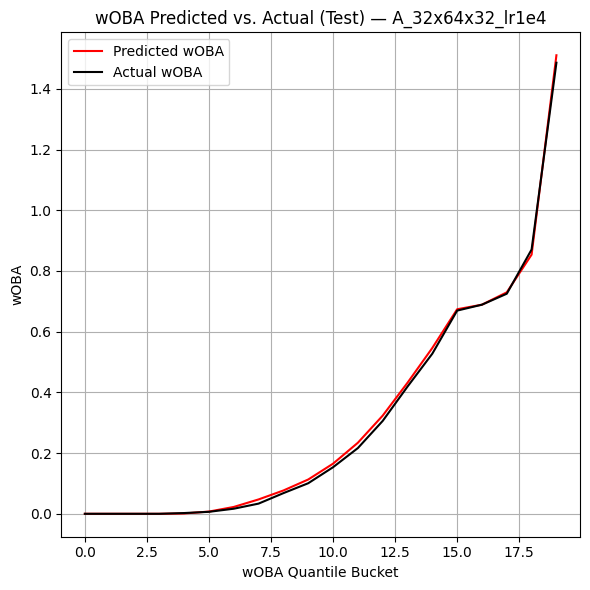


Best config per-output summary (testing window):
Year Output   Actual  Predicted  Multiplier  Std. Dev      MSE
 All     b1 0.142180   0.142800    0.995670  0.230640 0.000040
 All     b2 0.042080   0.046310    0.908570  0.112390 0.000070
 All     b3 0.003450   0.003430    1.007510  0.008550 0.000000
 All     bb 0.086230   0.086230    1.000000  0.280700 0.000000
 All     fo 0.136730   0.132620    1.030990  0.303550 0.000110
 All     go 0.220480   0.215400    1.023580  0.348080 0.000100
 All    hbp 0.010840   0.010840    1.000000  0.103540 0.000000
 All     hr 0.030650   0.031130    0.984390  0.143330 0.000000
 All     lo 0.057730   0.059700    0.967110  0.154330 0.000140
 All     po 0.047760   0.049670    0.961490  0.202290 0.000040
 All     so 0.221870   0.221870    1.000000  0.415500 0.000000
 All   wOBA 0.313700   0.320510    0.978750  0.402380 0.000130


In [20]:
# Plot the best config's wOBA calibration (predicted vs. actual by bucket, testing window).
if is_main == True and train_batted_ball_model == True:
    bdf = config_buckets[best_overall['config']]
    plt.figure(figsize=(6, 6))
    plt.plot(bdf['b'], bdf['pred'], color='red',   label='Predicted wOBA')
    plt.plot(bdf['b'], bdf['act'],  color='black', label='Actual wOBA')
    plt.title(f"wOBA Predicted vs. Actual (Test) — {best_overall['config']}")
    plt.xlabel('wOBA Quantile Bucket')
    plt.ylabel('wOBA')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("\nBest config per-output summary (testing window):")
    print(best_overall['summary'].round(5).to_string(index=False))

##### Predict

Predict rates of events based on batted-ball data

In [21]:
prediction_df = pd.DataFrame(predict_outcome.predict(X_scaled), columns=encode_outcome.categories_[0])
prediction_df = prediction_df.add_suffix('_pred_batted')

61601/61601 ━━━━━━━━━━━━━━━━━━━━ 29s 474us/step


Concatenate predictions onto plate appearance dataset

In [22]:
batted_ball_dataset = pd.concat([df.reset_index(drop=True), prediction_df], axis=1)

### Evaluate

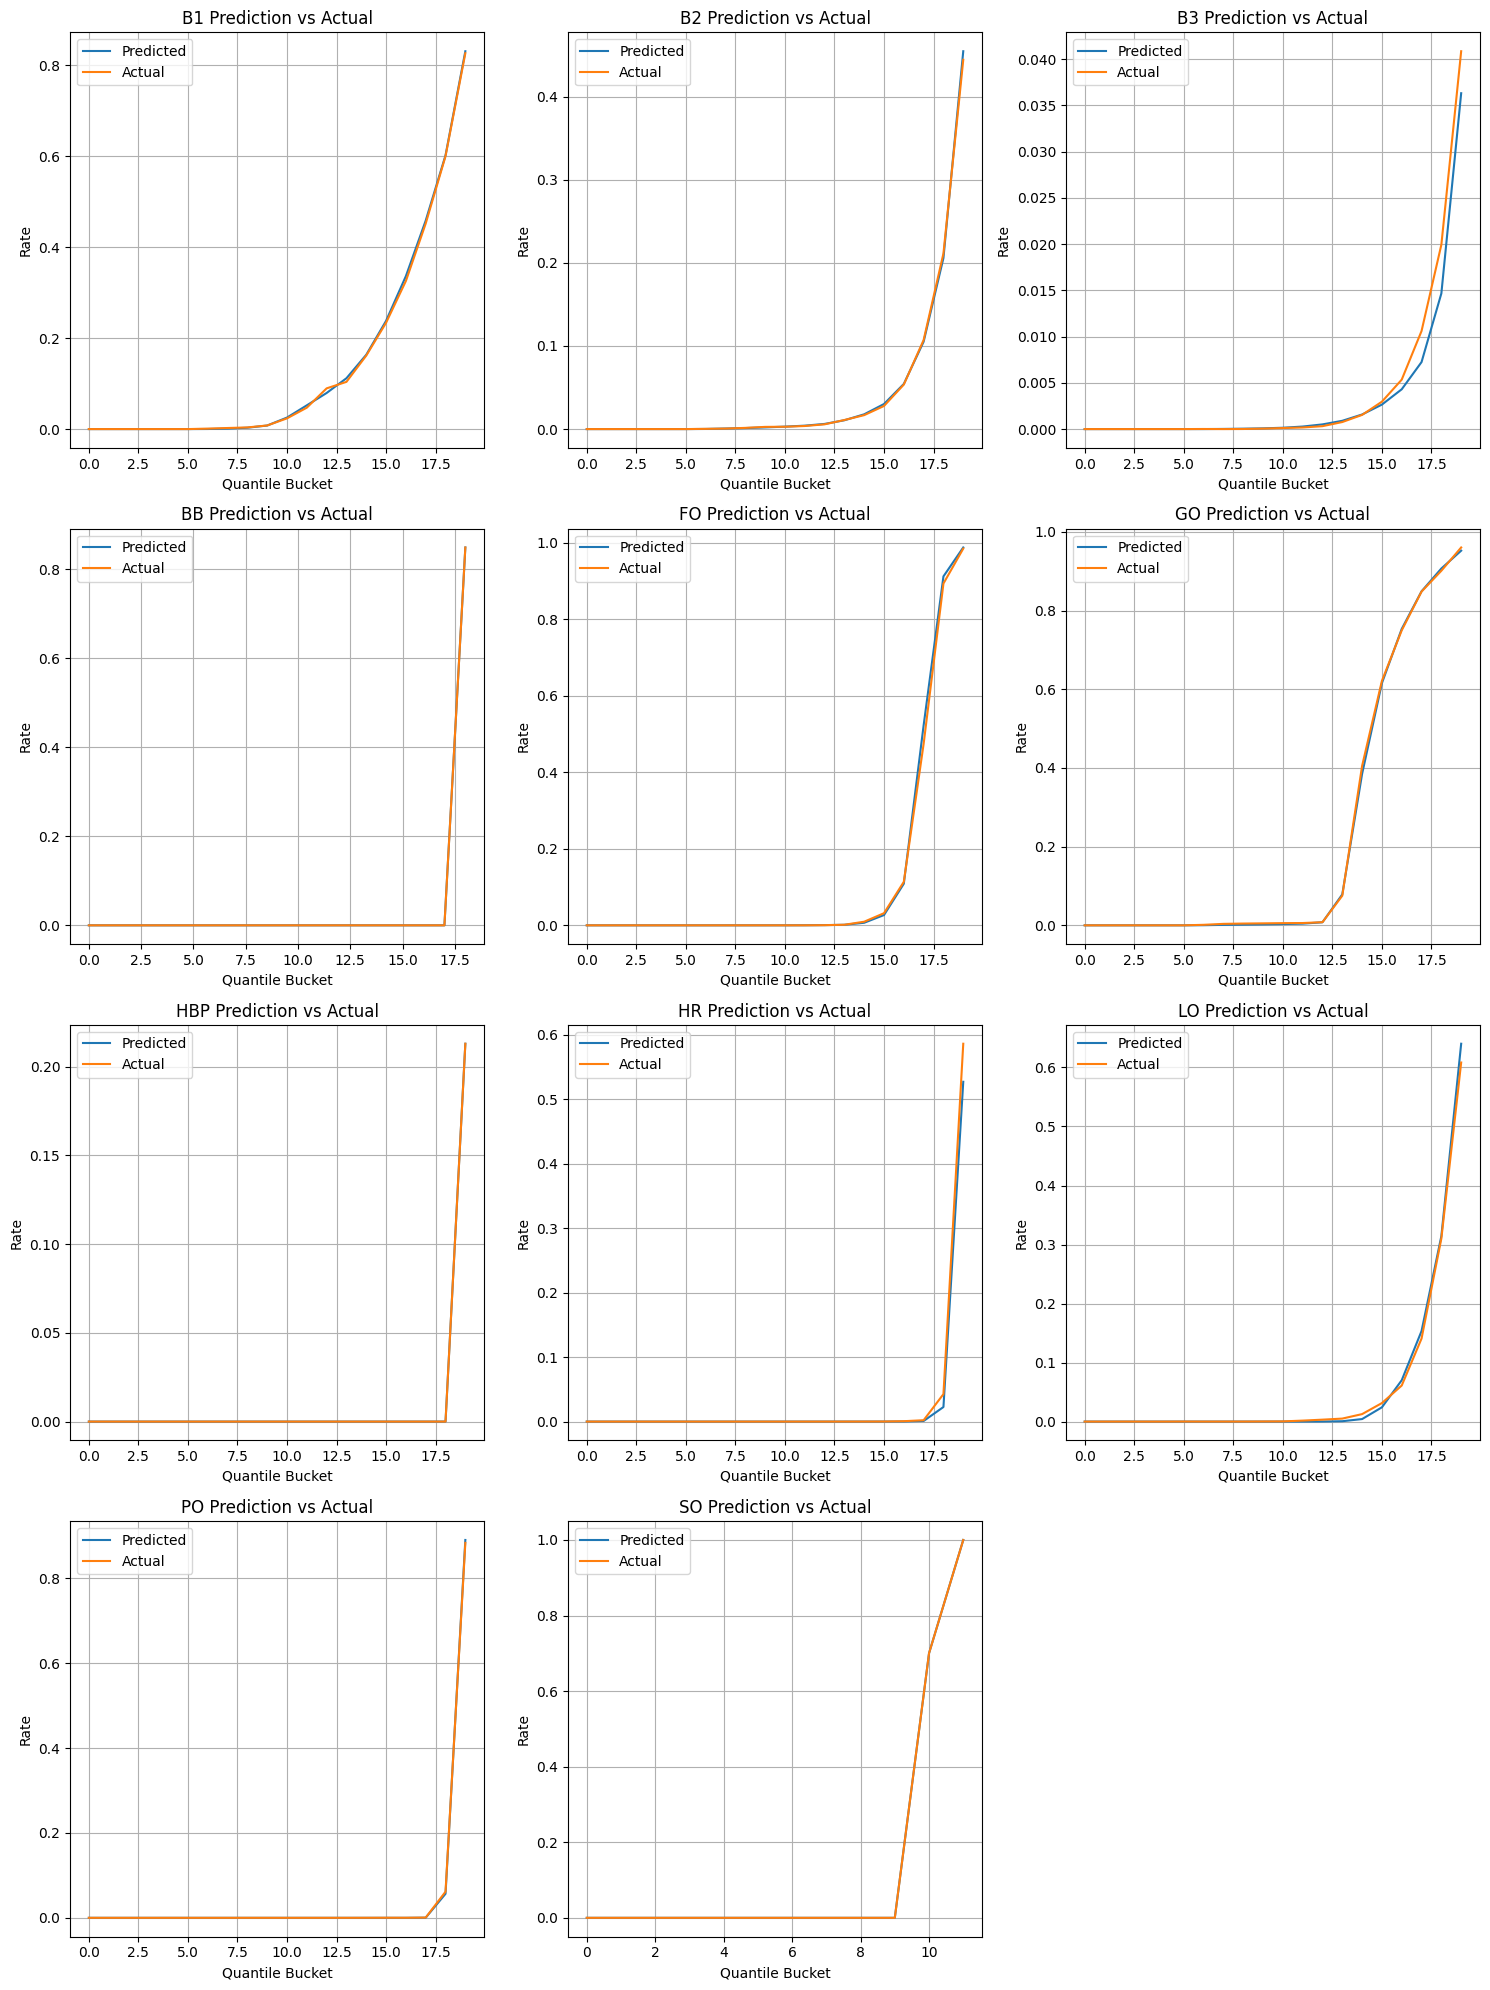

In [23]:
# Adjust the number of rows and columns
n_events = len(events_list)
n_cols = 3
n_rows = (n_events + n_cols - 1) // n_cols  # Ceiling division

# Set square plots: each subplot is 5x5 inches
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, event in enumerate(events_list):
    ax = axes[i]
    pred_col = f"{event}_pred_batted"

    if pred_col not in batted_ball_dataset.columns:
        continue

    # Bucket the predicted values into quantiles
    batted_ball_dataset['bucket'] = pd.qcut(batted_ball_dataset[pred_col], q=20, duplicates='drop')

    # Compute averages
    bucket_avg = batted_ball_dataset.groupby('bucket').agg(
        avg_pred=(pred_col, 'mean'),
        avg_actual=(event, 'mean')
    ).reset_index()

    # Plot
    ax.plot(bucket_avg['avg_pred'], label='Predicted')
    ax.plot(bucket_avg['avg_actual'], label='Actual')
    ax.set_title(f"{event.upper()} Prediction vs Actual")
    ax.set_xlabel("Quantile Bucket")
    ax.set_ylabel("Rate")
    ax.legend()
    ax.grid(True)

# Remove extra axes if any
for j in range(n_events, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Drop unneeded columns

In [24]:
if 'bucket' in list(batted_ball_dataset.columns):
    batted_ball_dataset.drop(columns=['bucket'], inplace=True)

### Park Alterations

Create separate venue_ids after major park alterations

In [25]:
batted_ball_dataset['venue_id_adj'] = batted_ball_dataset['venue_id'].astype(str)

batted_ball_dataset.loc[(batted_ball_dataset['venue_id'].astype(str) == '2') & (batted_ball_dataset['date'] < 20220101), 'venue_id_adj'] = '2A'                   # Camden Yards first adjustment
batted_ball_dataset.loc[(batted_ball_dataset['venue_id'].astype(str) == '2') & (batted_ball_dataset['date'].between(20220101, 20241231)), 'venue_id_adj'] = '2B'  # Camden Yards second adjustment
batted_ball_dataset.loc[(batted_ball_dataset['venue_id'].astype(str) == '7') & (batted_ball_dataset['date'] < 20260101), 'venue_id_adj'] = '7A'                   # Kauffman Stadium adjustment

### Calculate PFX

Create lists for containing batted ball predicted outcome rates and PFX

In [26]:
events_list_pred_batted = [f"{event}_pred_batted" for event in events_list]
pfx_list = [f"{event}_pfx" for event in events_list]

Calculate average actual event rates and predicted event rates by game and batSide

In [27]:
game_pfx_df = batted_ball_dataset.groupby(['venue_id', 'venue_id_adj', 'gamePk', 'batSide', 'date'])[events_list + events_list_pred_batted].mean().reset_index().sort_values(['venue_id', 'date', 'batSide'])

In [28]:
for (venue, side), group in game_pfx_df.groupby(['venue_id_adj', 'batSide']):
    if not group['date'].is_monotonic_increasing:
        print(f"venue={venue}, batSide={side}")
        print(group[['venue_id_adj', 'batSide', 'date']].head(10))
        break

In [29]:
def build_game_pfx_df(game_pfx_df, shift_val):
    """
    Compute rolling venue & league averages, shrink toward league, and calculate park factors.
    Uses venue_id_adj instead of venue_id for grouping.

    Parameters
    ----------
    game_pfx_df : pd.DataFrame
        Must contain 'venue_id_adj', 'batSide', events_list, events_list_pred_batted
    shift_val : int
        0 -> include current row
        1 -> exclude current row (predictive)
    """
    # -------------------------------------------------
    # Rolling venue averages
    # -------------------------------------------------
    rolling_avgs = (
        game_pfx_df
        .groupby(['venue_id_adj', 'batSide'], group_keys=False)
        .apply(lambda g:
            g[events_list + events_list_pred_batted]
            .shift(shift_val)
            .rolling(num_games, min_periods=1)
            .mean()
        )
    )
    rolling_avgs.columns = [f'{c}_rolling' for c in events_list + events_list_pred_batted]

    # -------------------------------------------------
    # Rolling sample size
    # -------------------------------------------------
    rolling_counts = (
        game_pfx_df
        .groupby(['venue_id_adj','batSide'], group_keys=False)
        .apply(lambda g:
            g[events_list[0]]
            .shift(shift_val)
            .rolling(num_games, min_periods=1)
            .count()
        )
    )
    rolling_counts.name = "rolling_sample_size"

    # -------------------------------------------------
    # Combine
    # -------------------------------------------------
    result_df = pd.concat([game_pfx_df, rolling_avgs, rolling_counts], axis=1)

    # -------------------------------------------------
    # League rolling averages
    # -------------------------------------------------
    league_rolling = (
        game_pfx_df
        .groupby(['batSide'], group_keys=False)
        .apply(lambda g:
            g[events_list + events_list_pred_batted]
            .shift(shift_val)
            .rolling(num_games, min_periods=1)
            .mean()
        )
    )
    league_rolling.columns = [f'{c}_league_rolling' for c in events_list + events_list_pred_batted]
    result_df = pd.concat([result_df, league_rolling], axis=1)

    # -------------------------------------------------
    # Shrink venue toward league for numerator (events_list)
    # -------------------------------------------------
    n = result_df["rolling_sample_size"]

    for event in events_list:
        venue_col = f"{event}_rolling"
        league_col = f"{event}_league_rolling"
        adj_col = f"{event}_rolling_adj"

        result_df[adj_col] = (
            n * result_df[venue_col] +
            (num_games - n) * result_df[league_col]
        ) / num_games

    # -------------------------------------------------
    # Shrink venue toward league for denominator (events_list_pred_batted)
    # -------------------------------------------------
    for event in events_list_pred_batted:
        venue_col = f"{event}_rolling"
        league_col = f"{event}_league_rolling"
        adj_col = f"{event}_rolling_adj"

        result_df[adj_col] = (
            n * result_df[venue_col] +
            (num_games - n) * result_df[league_col]
        ) / num_games

    # -------------------------------------------------
    # Park factors (shrunk numerator / shrunk denominator)
    # -------------------------------------------------
    for event in events_list:
        result_df[f"{event}_pfx"] = (result_df[f"{event}_rolling_adj"] / result_df[f"{event}_pred_batted_rolling_adj"])

    return result_df

In [30]:
unshifted_game_pfx_df = build_game_pfx_df(game_pfx_df, 0)
shifted_game_pfx_df   = build_game_pfx_df(game_pfx_df, 1)

Write to CSV

In [31]:
unshifted_game_pfx_df[['venue_id_adj', 'batSide'] + [col for col in unshifted_game_pfx_df if col.endswith("pfx")]].drop_duplicates(subset=['venue_id_adj', 'batSide'], keep='last').to_csv(os.path.join(baseball_path, "Park Latest.csv"), index=False)
shifted_game_pfx_df.to_csv(os.path.join(baseball_path, "PFX.csv"), index=False)

### Park Factor Summary

Latest park factors by venue and batter side, expressed as multipliers relative to league average (1.0 = league average). Composite metrics (wOBA, FP_B, FP_P) are the weighted sum of outcome rates at the park divided by the weighted sum at league average.

In [32]:
# Weights
pitcher_weights = {'fo': 1.0460, 'go': 1.0460, 'po': 1.0460, 'lo': 1.0460, 'so': 3.0408, 'bb': -1.3508, 'b1': -1.7427, 'b2': -1.7427, 'b3': -1.7427, 'hr': -3.6639}
batter_weights  = {'b1': 4.3665, 'b2': 6.8271, 'b3': 10.8503, 'hr': 15.2611, 'bb': 2.8725, 'hbp': 2.9639}
woba_weights    = {'b1': 0.882,  'b2': 1.254,  'b3': 1.590,   'hr': 2.050,   'bb': 0.689,  'hbp': 0.720}

# Venue name lookup — built from df before columns get dropped
# Sort by date so keep='last' gives the most recent name per venue
venue_names = (
    df[['venue_id', 'venue', 'date']].sort_values('date')
    .drop_duplicates(subset='venue_id', keep='last')
    .drop(columns='date')
    .copy()
)
venue_names['venue_id_adj'] = venue_names['venue_id'].astype(str)
# Add adjusted venue labels for parks with structural changes
venue_names = pd.concat([
    venue_names,
    venue_names[venue_names['venue_id_adj'] == '2'].assign(venue_id_adj='2A', venue='Camden Yards (pre-2022)'),
    venue_names[venue_names['venue_id_adj'] == '2'].assign(venue_id_adj='2B', venue='Camden Yards (2022-24)'),
    venue_names[venue_names['venue_id_adj'] == '7'].assign(venue_id_adj='7A', venue='Kauffman Stadium (pre-2026)'),
], ignore_index=True)

# Latest PFX per venue_id_adj x batSide (min 20 games sample size)
pfx_latest = (
    unshifted_game_pfx_df[['venue_id_adj', 'batSide', 'rolling_sample_size'] + pfx_list]
    .drop_duplicates(subset=['venue_id_adj', 'batSide'], keep='last')
    .query('rolling_sample_size >= 20')
    .reset_index(drop=True)
)

# Join venue names
pfx_latest = pfx_latest.merge(venue_names[['venue_id_adj', 'venue']], on='venue_id_adj', how='left')

# Compute composite multipliers
league_rates = (
    unshifted_game_pfx_df
    .drop_duplicates(subset=['venue_id_adj', 'batSide'], keep='last')
    .groupby('batSide')[[f'{e}_pred_batted_rolling_adj' for e in events_list]]
    .mean()
    .rename(columns={f'{e}_pred_batted_rolling_adj': e for e in events_list})
)

def composite_pfx(row, weights, league_rates_side):
    """Weighted-average PFX using league rates as weights, restricted to events in `weights`."""
    numer = denom = 0.0
    for event, w in weights.items():
        pfx_col = f'{event}_pfx'
        if pfx_col not in row.index or event not in league_rates_side.index:
            continue
        rate = league_rates_side[event]
        numer += abs(w) * rate * row[pfx_col]
        denom += abs(w) * rate
    return numer / denom if denom else float('nan')

for metric, weights in [('wOBA_pfx', woba_weights), ('FP_B_pfx', batter_weights), ('FP_P_pfx', pitcher_weights)]:
    pfx_latest[metric] = pfx_latest.apply(
        lambda row, w=weights: composite_pfx(row, w, league_rates.loc[row['batSide']]),
        axis=1
    )

# Display
display_cols = ['venue_id_adj', 'venue', 'batSide', 'rolling_sample_size'] + pfx_list + ['wOBA_pfx', 'FP_B_pfx', 'FP_P_pfx']
pfx_summary = pfx_latest[display_cols].sort_values(['venue_id_adj', 'batSide']).reset_index(drop=True).sort_values('wOBA_pfx', ascending=False)

# Style: highlight deviations from 1.0
def style_pfx(val):
    if not isinstance(val, float):
        return ''
    dev = val - 1.0
    intensity = min(int(abs(dev) * 400), 180)
    if dev > 0:
        return f'background-color: rgba(0,180,0,{intensity/255:.2f})'
    elif dev < 0:
        return f'background-color: rgba(220,0,0,{intensity/255:.2f})'
    return ''

pfx_summary.style \
    .applymap(style_pfx, subset=pfx_list + ['wOBA_pfx', 'FP_B_pfx', 'FP_P_pfx']) \
    .format({'rolling_sample_size': '{:.0f}'}, subset=['rolling_sample_size']) \
    .format({col: '{:.3f}' for col in pfx_list + ['wOBA_pfx', 'FP_B_pfx', 'FP_P_pfx']}) \
    .set_caption('Park Factors by Venue and Batter Side (multipliers vs. league avg)')

,venue_id_adj,venue,batSide,rolling_sample_size,b1_pfx,b2_pfx,b3_pfx,bb_pfx,fo_pfx,go_pfx,hbp_pfx,hr_pfx,lo_pfx,po_pfx,so_pfx,wOBA_pfx,FP_B_pfx,FP_P_pfx
40,2756,Sahlen Field.,L,49.000000,0.892,1.241,1.567,1.000,0.948,1.008,1.000,1.543,0.870,1.114,1.000,1.118,1.165,1.028
6,13,Globe Life Park in Arlington.,L,81.000000,0.995,1.151,1.141,1.000,0.878,1.003,1.000,1.394,0.932,1.011,1.000,1.104,1.134,1.020
7,13,Globe Life Park in Arlington.,R,81.000000,1.011,1.175,1.792,1.000,0.902,0.975,1.000,1.244,0.995,1.029,1.000,1.096,1.117,1.017
30,2529,Sutter Health Park.,L,81.000000,1.004,1.179,0.723,1.000,0.941,1.018,1.000,1.318,0.874,0.876,1.000,1.088,1.110,1.017
16,19,Coors Field.,L,81.000000,1.086,1.074,2.071,1.000,1.041,0.965,1.000,1.097,0.936,0.621,1.000,1.088,1.099,1.012
32,2536,TD Ballpark.,L,22.000000,0.977,1.163,1.733,1.000,0.984,1.001,1.000,1.222,0.789,1.038,1.000,1.078,1.100,1.014
33,2536,TD Ballpark.,R,22.000000,1.001,1.105,0.737,1.000,1.020,0.986,1.000,1.300,0.861,0.918,1.000,1.076,1.097,1.016
38,2681,Citizens Bank Park.,L,81.000000,1.050,0.944,1.087,1.000,0.968,0.960,1.000,1.286,1.037,0.886,1.000,1.067,1.087,1.013
31,2529,Sutter Health Park.,R,81.000000,1.018,1.050,0.643,1.000,0.984,1.003,1.000,1.245,0.943,0.912,1.000,1.060,1.077,1.014
44,2A,Camden Yards (pre-2022),L,81.000000,0.950,1.170,0.655,1.000,0.929,1.054,1.000,1.290,0.830,0.995,1.000,1.059,1.081,1.013


### Plate Appearance Dataset

This creates a dataset with PA-level data used in several subsequent models

Replace actual event rates with predicted ones

In [33]:
batted_ball_dataset[events_list] = batted_ball_dataset[events_list_pred_batted].copy()

Calculate rolling stats

Short

In [34]:
df_short = rolling_pas(batted_ball_dataset, short, events_list)

Long

In [35]:
df_long = rolling_pas(batted_ball_dataset, long, events_list)
df_long = df_long.add_suffix("_long")

Merge long stats onto rolling (and other) stats

In [36]:
pa_dataset = pd.concat([df_short, df_long[batter_stats_long + pitcher_stats_long]], axis=1)  # Only need to take the rolling stats from long since the rest are in short
pa_dataset.sort_values(['date', 'gamePk', 'atBatIndex'], ascending=True, inplace=True)
pa_dataset.drop(columns=events_list + ['Cut'], inplace=True)

Add event dummies

In [37]:
event_dummies = pd.get_dummies(pa_dataset['eventsModel']).astype(int)
for col in event_dummies.columns:
    pa_dataset[col] = event_dummies[col].values
del event_dummies

Clean

In [38]:
pa_dataset = pa_dataset.replace([float('inf'), float('-inf')], 0)

Write to CSV

In [39]:
pa_dataset.to_csv(os.path.join(baseball_path, "PA Dataset.csv"), index=False)

In [40]:
print(f"Data as of {pa_dataset['date'].max()}.")

Data as of 20260701.


### Required Follow-Ups:
- Model A. Batted Ball
    - Model B. Park and Weather Factors
    - B01. Matchups
    - M02. Stat Imputations
    - M03. Plate Appearances

Note: You should avoid retraining Model A. Batted Ball as much as possible. It's slow. Likely shouldn't need many updates anyway. 

You can run B01. Matchups from here! Just make sure to comment this out when not needed or it will run from outer notebooks

### Settings

In [55]:
# start_date = '20260101'
# end_date = '20261231'

### Games

Refresh game dataset

In [56]:
# all_game_df = create_games(team_dict=team_dict, baseball_path=baseball_path, venue_map_df=venue_map_df, refresh_start_date=yesterdaysdate, refresh_end_date=todaysdate)

Select games

In [57]:
# game_df = all_game_df[(all_game_df['date'].astype(str) >= str(start_date)) & (all_game_df['date'].astype(str) <= str(end_date))].reset_index(drop=True)

Fill in missing starters

In [58]:
# game_df[['home_probable_pitcher', 'away_probable_pitcher']] = game_df[['home_probable_pitcher', 'away_probable_pitcher']].fillna("Missing Starter")

### B01. Matchups

Date(s): Yesterday and Today

In [59]:
# df = game_df[(game_df['date'].astype(int) >= int(start_date)) & (game_df['date'].astype(int) <= int(end_date))].reset_index(drop=True)

In [60]:
# %%time
# create_all_matchups(df, baseball_path, team_dict, batter_inputs, pitcher_inputs, start_date)